In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('Medical_Risk_Classification.csv')
df.head()

,Biomarker_A,Biomarker_B,BMI,Age,Smoking_Status,Family_History,BMI_Squared,Age_Normalized,High_Risk
0,1.572821,0.719531,20.921853,76.852031,Non-Smoker,Yes,437.723931,0.960650,1
1,0.421854,1.924399,19.006796,41.350755,Current,No,361.258302,0.516884,1
2,3.425030,5.205850,19.791748,34.992573,Non-Smoker,Yes,391.713285,0.437407,1
3,3.538766,1.395408,21.139071,56.973044,Current,Yes,446.860330,0.712163,1
4,1.799962,3.646175,23.798603,49.932369,Non-Smoker,No,566.373523,0.624155,0


In [3]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

In [4]:
le = LabelEncoder()

for i in range(X.shape[1]):
    if isinstance(X[0, i], str):
        X[:, i] = le.fit_transform(X[:, i])

Y = le.fit_transform(Y)

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

In [7]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)

dummy_pred = dummy.predict(X_test)

print("Baseline Accuracy:", accuracy_score(Y_test, dummy_pred))

Baseline Accuracy: 0.864


In [8]:
nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)

Y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 score:", f1_score(Y_test, Y_pred))

print(classification_report(Y_test, Y_pred))

Accuracy: 0.956
Precision: 0.9555555555555556
Recall: 0.9953703703703703
F1 score: 0.9750566893424036
              precision    recall  f1-score   support

           0       0.96      0.71      0.81        34
           1       0.96      1.00      0.98       216

    accuracy                           0.96       250
   macro avg       0.96      0.85      0.89       250
weighted avg       0.96      0.96      0.95       250



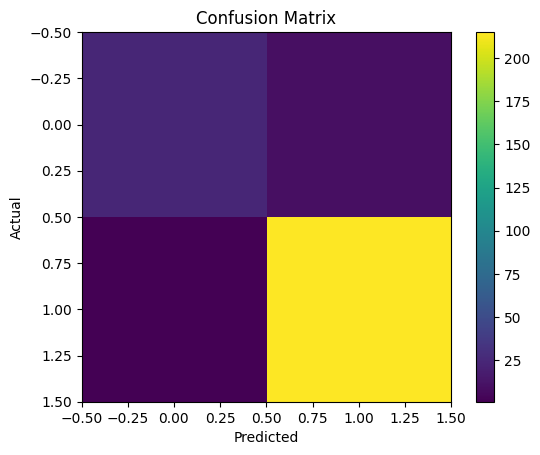

In [9]:
cm=confusion_matrix(Y_test, Y_pred)

plt.figure()
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

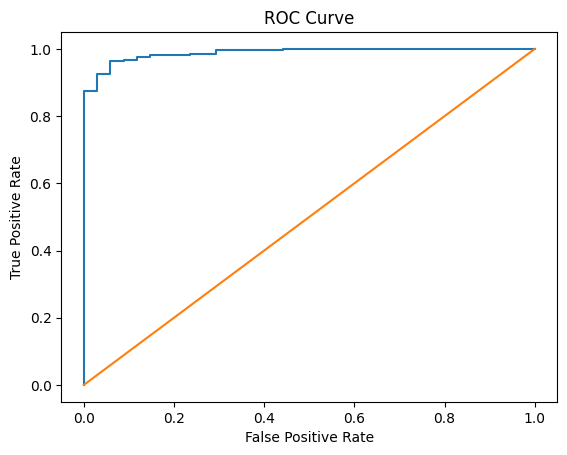

AUC Score: 0.9882897603485838


In [11]:
Y_prob = nb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

auc = roc_auc_score(Y_test, Y_prob)

print("AUC Score:", auc)

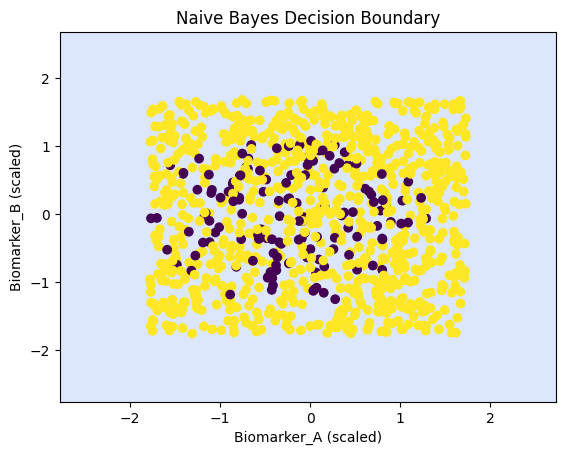

In [16]:
X_vis = df[['Biomarker_A','Biomarker_B']].values
Y = df['High_Risk'].values

scaler = StandardScaler()
X_vis = scaler.fit_transform(X_vis)

nb_vis = GaussianNB()
nb_vis.fit(X_vis, Y)

X_range = np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200)
Y_range = np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200)

xx, yy = np.meshgrid(X_range, Y_range)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = nb_vis.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis[:,0], X_vis[:,1], c=Y)

plt.xlabel("Biomarker_A (scaled)")
plt.ylabel("Biomarker_B (scaled)")
plt.title("Naive Bayes Decision Boundary")

plt.show()